# Pontifícia Universidade Católica de Minas Gerais
## Pós-Graduação em IA Generativa e Aplicações com LLMs
### Disciplina: Arquiteturas de Deep Learning

# Previsão de Demanda em Mobilidade Urbana com Redes Neurais Recorrentes (RNNs)

> Nesta atividade, construímos e comparamos três arquiteturas de redes neurais recorrentes
> (SimpleRNN, LSTM e GRU) para prever a demanda de aluguel de bicicletas na próxima hora,
> com base no histórico das últimas 24 horas e em variáveis climáticas e temporais.

---

| Campo | Detalhe |
|:------|:--------|
| **Instituição** | Pontifícia Universidade Católica de Minas Gerais |
| **Programa** | Pós-Graduação em IA Generativa e Aplicações com LLMs |
| **Disciplina** | Arquiteturas de Deep Learning |
| **Professor** | Antônio dos Santos Ramos Neto |
| **Aluno** | Jair Pereira da Silva Junior |
| **Dataset** | Bike Sharing Dataset (UCI Machine Learning Repository) |
| **Fonte** | [Kaggle — Bike Sharing Dataset](https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset) |
| **Registros** | 17.379 registros horários (2011–2012) |
| **Variável alvo** | `cnt` — total de bicicletas alugadas por hora |
| **Modelos** | SimpleRNN, LSTM, GRU |
| **Objetivo** | Construir e comparar modelos recorrentes para prever a demanda da próxima hora. |
| **Data de Entrega** | Conforme informado no ambiente da disciplina |

---


## Contexto de Negocio

Uma empresa de **mobilidade urbana** opera bicicletas compartilhadas.
Prever a demanda nas proximas horas ajuda a:

- Reposicionar bicicletas entre estacoes;
- Planejar equipes de manutencao;
- Antecipar horarios de pico;
- Reduzir estacoes vazias ou superlotadas.

> **Ideia chave:** Sabendo o comportamento das ultimas 24 horas + condicoes climaticas,
> o modelo aprende a prever a demanda da proxima hora!


## Dataset: Bike Sharing (UCI Machine Learning Repository)

**17.379 registros horarios** - Capital Bikeshare, Washington D.C. (2011-2012)

| Coluna | Significado |
|--------|--------------|
| `hr` | Hora do dia (0 a 23) |
| `temp` | Temperatura normalizada (dividida por 41 graus C) |
| `hum` | Umidade relativa normalizada |
| `windspeed` | Velocidade do vento normalizada |
| `season` | Estacao: 1=primavera, 2=verao, 3=outono, 4=inverno |
| `weekday` | Dia da semana (0=domingo) |
| `workingday` | 1=dia util, 0=fim de semana/feriado |
| `weathersit` | Clima: 1=claro, 2=nublado, 3=chuva leve, 4=chuva forte |
| **`cnt`** | **Bicicletas alugadas** <- variavel alvo |


## Passo 1 - Importar Bibliotecas

Vamos importar todas as ferramentas necessarias:


In [31]:
# Dados e calculos
import numpy as np
import pandas as pd

# Visualizacao
import matplotlib.pyplot as plt
import seaborn as sns

# Pre-processamento e metricas
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Configuracoes
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('TensorFlow:', tf.__version__)
print('Importacoes concluidas!')


TensorFlow: 2.21.0
Importacoes concluidas!


## Passo 2 - Hiperparametros Globais

Centralizar os parametros facilita ajustes futuros:


In [32]:
# Janela temporal
WINDOW_SIZE = 24   # quantas horas do passado o modelo vai ver

# Features e alvo
FEATURES   = ['hr', 'temp', 'hum', 'windspeed',
               'season', 'weekday', 'workingday', 'weathersit', 'cnt']
TARGET_COL = 'cnt'
TARGET_IDX = FEATURES.index(TARGET_COL)   # indice de cnt na lista
N_FEATURES = len(FEATURES)

# Treinamento
UNITS      = 64    # neuronios na camada recorrente
EPOCHS     = 30
BATCH_SIZE = 64
PATIENCE   = 5
VALIDATION = 0.15

print(f'Janela de entrada : {WINDOW_SIZE} horas')
print(f'Numero de features: {N_FEATURES}')
print(f'Indice do alvo    : {TARGET_IDX}  (coluna "{TARGET_COL}")')


Janela de entrada : 24 horas
Numero de features: 9
Indice do alvo    : 8  (coluna "cnt")


## Passo 3 - Carregar e Explorar os Dados


In [33]:
df = pd.read_csv('dataset/hour.csv', parse_dates=['dteday'])

print(f'Shape: {df.shape[0]} linhas x {df.shape[1]} colunas')
print(f'Periodo: {df["dteday"].min().date()} -> {df["dteday"].max().date()}')
df.head()


Shape: 17379 linhas x 17 colunas
Periodo: 2011-01-01 -> 2012-12-31


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [34]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[us]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-null  int64

In [35]:
df[FEATURES].describe().round(3)


,hr,temp,hum,windspeed,season,weekday,workingday,weathersit,cnt
count,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000
mean,11.547,0.497,0.627,0.190,2.502,3.004,0.683,1.425,189.463
std,6.914,0.193,0.193,0.122,1.107,2.006,0.465,0.639,181.388
min,0.000,0.020,0.000,0.000,1.000,0.000,0.000,1.000,1.000
25%,6.000,0.340,0.480,0.104,2.000,1.000,0.000,1.000,40.000
50%,12.000,0.500,0.630,0.194,3.000,3.000,1.000,1.000,142.000
75%,18.000,0.660,0.780,0.254,3.000,5.000,1.000,2.000,281.000
max,23.000,1.000,1.000,0.851,4.000,6.000,1.000,4.000,977.000


## Passo 4 - Visualizacao da Serie Temporal

Antes de qualquer modelagem, **visualizamos** os dados para entender:
- Ha sazonalidade (padrao que se repete a cada dia/semana)?
- Existem picos ou anomalias?
- A serie cresce ao longo do tempo?


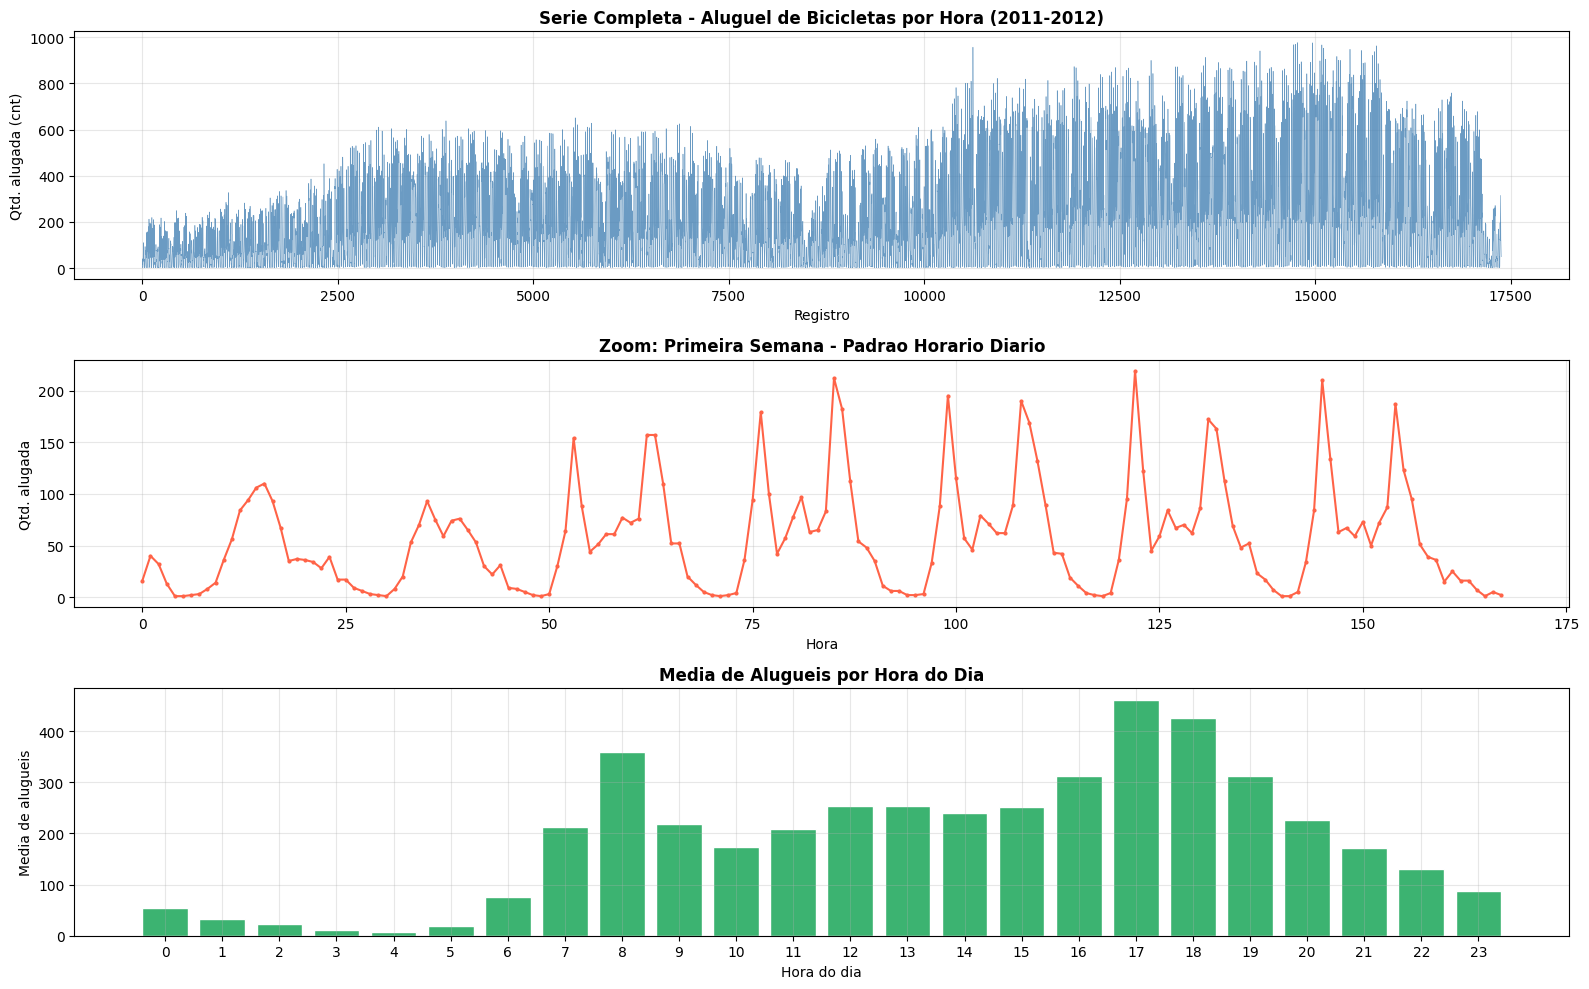

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# 1) Serie completa
axes[0].plot(df.index, df['cnt'], color='steelblue', linewidth=0.4, alpha=0.8)
axes[0].set_title('Serie Completa - Aluguel de Bicicletas por Hora (2011-2012)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Registro')
axes[0].set_ylabel('Qtd. alugada (cnt)')

# 2) Zoom: primeira semana (168 horas)
semana = df.iloc[:168]
axes[1].plot(range(len(semana)), semana['cnt'],
             color='tomato', linewidth=1.5, marker='o', markersize=2)
axes[1].set_title('Zoom: Primeira Semana - Padrao Horario Diario',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Qtd. alugada')

# 3) Media por hora do dia
media_hora = df.groupby('hr')['cnt'].mean()
axes[2].bar(media_hora.index, media_hora.values,
            color='mediumseagreen', edgecolor='white')
axes[2].set_title('Media de Alugueis por Hora do Dia',
                   fontsize=12, fontweight='bold')
axes[2].set_xlabel('Hora do dia')
axes[2].set_ylabel('Media de alugueis')
axes[2].set_xticks(range(24))

plt.tight_layout()
plt.savefig('serie_temporal.png', dpi=120, bbox_inches='tight')
plt.show()


## Passo 5 - Pre-processamento

### Por que normalizar?

Redes neurais convergem melhor quando os valores estao em escalas semelhantes.
Usamos o **MinMaxScaler**, ajustado exclusivamente no periodo de treino:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

> **Atencao:** primeiro definimos o corte cronologico. O scaler aprende minimo e
> maximo apenas com o treino; teste e transformado sem reajuste. Isso evita
> *data leakage*, isto e, o uso de informacoes do futuro durante o treinamento.

As previsoes sao posteriormente convertidas para a escala original de bicicletas.


In [37]:
# Selecionar as colunas de interesse
dados_brutos = df[FEATURES].values.astype(np.float32)

# O corte e definido pelo instante previsto por cada janela.
n_janelas = len(dados_brutos) - WINDOW_SIZE
n_treino = int(n_janelas * 0.80)
indice_corte = WINDOW_SIZE + n_treino

print(f'Shape dos dados brutos: {dados_brutos.shape}')
print(f'Corte cronologico: indice {indice_corte} de {len(dados_brutos)}')
print(f'Periodo usado para ajustar o scaler: 0 a {indice_corte - 1}')


Shape dos dados brutos: (17379, 9)
Corte cronologico: indice 13908 de 17379
Periodo usado para ajustar o scaler: 0 a 13907


In [38]:
# Ajustar o scaler somente no treino e transformar toda a serie
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(dados_brutos[:indice_corte])
dados_norm = scaler.transform(dados_brutos)

print(f'Shape normalizado: {dados_norm.shape}')
print(f'Treino normalizado - min: {dados_norm[:indice_corte].min():.3f} | '
      f'max: {dados_norm[:indice_corte].max():.3f}')
print('Teste foi apenas transformado, sem reajuste do scaler.')


Shape normalizado: (17379, 9)
Treino normalizado - min: 0.000 | max: 1.000
Teste foi apenas transformado, sem reajuste do scaler.


## Passo 6 - Janelas Temporais (Sliding Window)

**Como funciona a janela deslizante?**

Imagine percorrer a serie hora a hora, coletando
sempre as ultimas 24 horas como **entrada** e a hora seguinte como **saida**:

```
 horas [0..23]  ->  preve hora [24]
 horas [1..24]  ->  preve hora [25]
 horas [2..25]  ->  preve hora [26]
   ...                   ...
```

**Resultado:**
- `X`: array 3D com shape `(n amostras, 24, 9 features)`
- `y`: array 1D com a quantidade alugada na hora seguinte


In [39]:
def criar_janelas(dados, tamanho_janela, indice_alvo):
    """
    Cria pares (X, y) com a tecnica de janela deslizante.

    Args:
        dados          : array 2D normalizado (n_amostras, n_features)
        tamanho_janela : numero de horas de entrada
        indice_alvo    : coluna-alvo dentro de dados

    Returns:
        X : (n_janelas, tamanho_janela, n_features)
        y : (n_janelas,)
    """
    X_list, y_list = [], []
    for i in range(len(dados) - tamanho_janela):
        X_list.append(dados[i : i + tamanho_janela, :])
        y_list.append(dados[i + tamanho_janela, indice_alvo])
    return np.array(X_list), np.array(y_list)


X, y = criar_janelas(dados_norm, WINDOW_SIZE, TARGET_IDX)

print(f'Shape de X: {X.shape}  ->  (amostras, horas_passadas, features)')
print(f'Shape de y: {y.shape}  ->  (amostras,)')


Shape de X: (17355, 24, 9)  ->  (amostras, horas_passadas, features)
Shape de y: (17355,)  ->  (amostras,)


## Passo 7 - Divisao Treino / Teste

**Por que nao embaralhar os dados?**  
Em series temporais, a **ordem cronologica importa**. Embaralhar antes da
divisao permitiria que o modelo fosse avaliado em dados anteriores aos usados
no treinamento.

Dividimos mantendo a ordem:
- **Treino:** primeiras 80% das janelas;
- **Teste:** ultimas 20% das janelas;
- O scaler foi ajustado somente nos registros usados pelo treino;
- A validacao usa o trecho final do treino, tambem sem embaralhamento.


In [40]:
X_treino, X_teste = X[:n_treino], X[n_treino:]
y_treino, y_teste = y[:n_treino], y[n_treino:]

print(f'Treino : {X_treino.shape[0]:,} amostras '
      f'({100 * X_treino.shape[0] / len(X):.0f}%)')
print(f'Teste  : {X_teste.shape[0]:,} amostras '
      f'({100 * X_teste.shape[0] / len(X):.0f}%)')

# Valores reais na escala original, alinhados aos alvos das janelas de teste
y_real_teste = dados_brutos[indice_corte:, TARGET_IDX]
assert len(y_real_teste) == len(y_teste)
print(f'cnt no teste - min: {y_real_teste.min():.0f}, '
      f'max: {y_real_teste.max():.0f}')


Treino : 13,884 amostras (80%)
Teste  : 3,471 amostras (20%)
cnt no teste - min: 1, max: 977


## Passo 8 - Funcoes Auxiliares

Criamos funcoes reutilizaveis para:
1. **Desnormalizar** previsoes e limitar contagens ao dominio nao negativo;
2. **Calcular metricas** (MAE, RMSE, R2 e MAPE);
3. **Plotar** curvas de treino e graficos Real x Previsto.

### Sobre as metricas

| Metrica | O que mede | Melhor valor |
|---------|------------|--------------|
| **MAE** | Erro medio em bicicletas | Menor |
| **RMSE** | Penaliza erros grandes | Menor |
| **R2** | Variancia explicada | Maior |
| **MAPE** | Erro percentual medio; ignora alvos iguais a zero | Menor |


In [41]:
def desnormalizar_cnt(valores):
    """Converte cnt normalizado para a escala original."""
    dummy = np.zeros((len(valores), N_FEATURES))
    dummy[:, TARGET_IDX] = np.asarray(valores).squeeze()
    return scaler.inverse_transform(dummy)[:, TARGET_IDX]


def garantir_contagens_validas(valores):
    """Contagens previstas nao podem ser negativas."""
    return np.clip(np.asarray(valores), 0, None)


def calcular_metricas(nome, real, pred):
    """Retorna MAE, RMSE, R2 e MAPE na escala original."""
    real = np.asarray(real)
    pred = np.asarray(pred)
    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    r2 = r2_score(real, pred)
    mascara = real != 0
    mape = np.mean(np.abs((real[mascara] - pred[mascara]) / real[mascara])) * 100
    return {
        'Modelo': nome,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 4),
        'MAPE (%)': round(mape, 2),
    }


def plotar_historico(hist, titulo):
    """Curvas de loss e MAE durante o treinamento."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, met, cor in zip(axes, ['loss', 'mae'], ['steelblue', 'darkorange']):
        ax.plot(hist.history[met], label='Treino', color=cor, lw=2)
        ax.plot(
            hist.history[f'val_{met}'],
            label='Validacao',
            color=cor,
            lw=2,
            ls='--',
        )
        ax.set_title(f'{titulo} - {met.upper()}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoca')
        ax.legend()
    plt.tight_layout()
    plt.savefig(f'historico_{titulo.lower()}.png', dpi=100, bbox_inches='tight')
    plt.show()


def plotar_previsao(real, pred, titulo, n=500):
    """Grafico Real x Previsto para os primeiros n pontos."""
    plt.figure(figsize=(16, 4))
    plt.plot(real[:n], label='Real', color='steelblue', lw=1.5)
    plt.plot(pred[:n], label='Previsto', color='tomato', lw=1.5, ls='--')
    plt.title(
        f'{titulo} - Real x Previsto (primeiros {n} pontos do teste)',
        fontsize=12,
        fontweight='bold',
    )
    plt.xlabel('Hora')
    plt.ylabel('Bicicletas alugadas')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'previsao_{titulo.lower()}.png', dpi=100, bbox_inches='tight')
    plt.show()


resultados = []
previsoes = {}
print('Funcoes auxiliares definidas!')


Funcoes auxiliares definidas!


---
## Modelo 1 - SimpleRNN

A **SimpleRNN** e a rede recorrente mais basica.
Em cada passo de tempo calcula:

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b)$$

Onde:
- $h_{t-1}$ = estado oculto anterior (memoria)
- $x_t$ = entrada atual (9 features)
- $W_h, W_x, b$ = pesos aprendidos no treinamento

**Limitacao principal:** Em sequencias longas, os gradientes tendem a
desaparecer (*vanishing gradient*), dificultando o aprendizado de
padroes de longo prazo como sazonalidade semanal.


In [42]:
def criar_simple_rnn(n_steps, n_features, unidades):
    modelo = keras.Sequential([
        layers.Input(shape=(n_steps, n_features)),
        layers.SimpleRNN(unidades, activation='tanh'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ], name='SimpleRNN')
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae'],
    )
    return modelo


rnn = criar_simple_rnn(WINDOW_SIZE, N_FEATURES, UNITS)
rnn.summary()


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
print('Treinando SimpleRNN...')
es = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=PATIENCE, restore_best_weights=True)

hist_rnn = rnn.fit(
    X_treino, y_treino,
    validation_split=VALIDATION,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    shuffle=False,
    verbose=1,
)
print(f'Concluido em {len(hist_rnn.history["loss"])} epocas.')


Treinando SimpleRNN...
Epoch 1/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0102 - mae: 0.0760 - val_loss: 0.0106 - val_mae: 0.0728
Epoch 2/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0053 - mae: 0.0555 - val_loss: 0.0060 - val_mae: 0.0583
Epoch 3/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0043 - mae: 0.0498 - val_loss: 0.0047 - val_mae: 0.0516
Epoch 4/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0036 - mae: 0.0451 - val_loss: 0.0040 - val_mae: 0.0475
Epoch 5/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0032 - mae: 0.0417 - val_loss: 0.0037 - val_mae: 0.0451
Epoch 6/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0029 - mae: 0.0401 - val_loss: 0.0034 - val_mae: 0.0433
Epoch 7/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0027 - mae: 0.0389 - val_loss: 0.0033 - val_mae: 0.0421
Epoch 8/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0026 - mae: 0.0382 - val_loss: 0.0032 - val_mae: 0.0413
Epoch 9/30
185/185 ━━━━━━━━━━━━

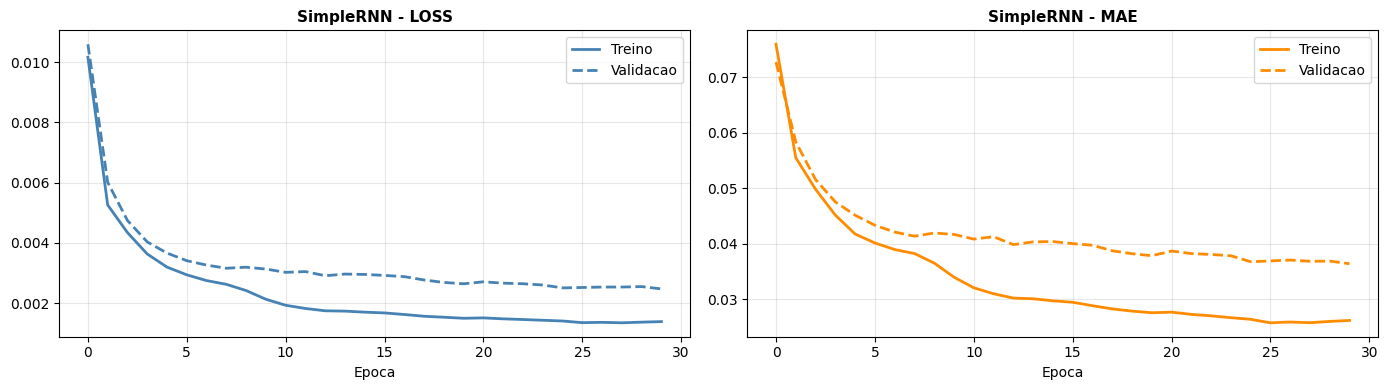

In [44]:
plotar_historico(hist_rnn, 'SimpleRNN')


In [45]:
# Prever, desnormalizar e restringir ao dominio de contagens
y_pred_rnn = desnormalizar_cnt(rnn.predict(X_teste).squeeze())
y_pred_rnn = garantir_contagens_validas(y_pred_rnn)
previsoes['SimpleRNN'] = y_pred_rnn

m_rnn = calcular_metricas('SimpleRNN', y_real_teste, y_pred_rnn)
resultados.append(m_rnn)
print(m_rnn)


109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
{'Modelo': 'SimpleRNN', 'MAE': 41.54, 'RMSE': 58.08, 'R2': 0.9307, 'MAPE (%)': 44.12}


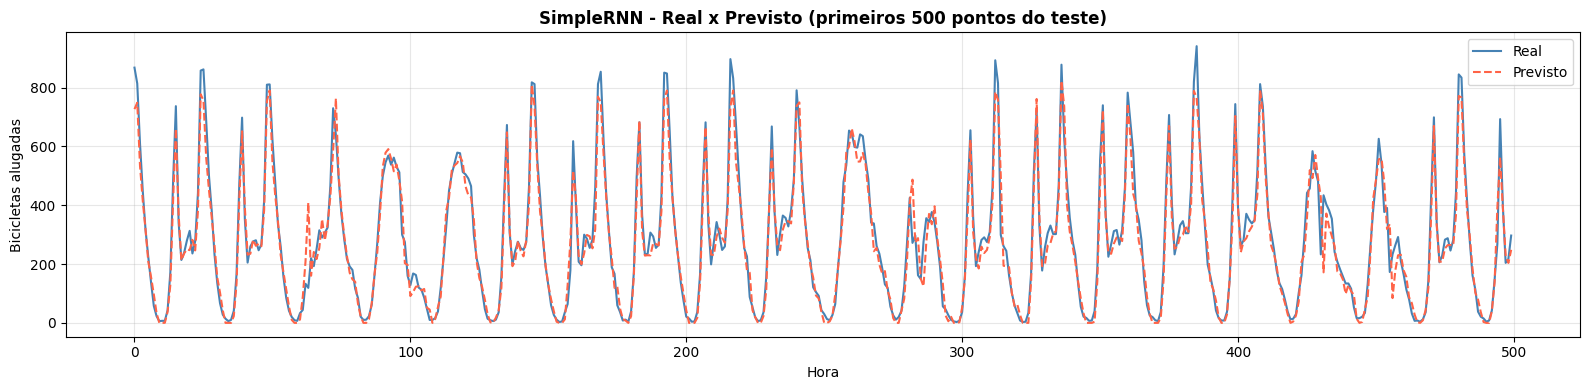

In [46]:
plotar_previsao(y_real_teste, y_pred_rnn, 'SimpleRNN')


---
## Modelo 2 - LSTM (Long Short-Term Memory)

A LSTM foi criada para superar o *vanishing gradient* com **tres portoes**:

| Portao | Funcao |
|--------|--------|
| **Forget gate** | Decide o que esquecer da memoria anterior |
| **Input gate** | Decide o que adicionar a memoria |
| **Output gate** | Decide o que usar como saida |

Esses portoes permitem que a LSTM retenha informacoes por muitos passos de tempo,
capturando padroes semanais e sazonais na demanda de bicicletas.

**Desvantagem:** Mais parametros que a SimpleRNN - treinamento mais lento.


In [47]:
def criar_lstm(n_steps, n_features, unidades):
    modelo = keras.Sequential([
        layers.Input(shape=(n_steps, n_features)),
        layers.LSTM(unidades),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ], name='LSTM')
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae'],
    )
    return modelo


lstm = criar_lstm(WINDOW_SIZE, N_FEATURES, UNITS)
lstm.summary()


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
print('Treinando LSTM...')
es = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=PATIENCE, restore_best_weights=True)

hist_lstm = lstm.fit(
    X_treino, y_treino,
    validation_split=VALIDATION,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    shuffle=False,
    verbose=1,
)
print(f'Concluido em {len(hist_lstm.history["loss"])} epocas.')


Treinando LSTM...
Epoch 1/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0113 - mae: 0.0784 - val_loss: 0.0202 - val_mae: 0.1109
Epoch 2/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0074 - mae: 0.0617 - val_loss: 0.0137 - val_mae: 0.0882
Epoch 3/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0059 - mae: 0.0548 - val_loss: 0.0104 - val_mae: 0.0747
Epoch 4/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0049 - mae: 0.0502 - val_loss: 0.0089 - val_mae: 0.0723
Epoch 5/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0041 - mae: 0.0463 - val_loss: 0.0068 - val_mae: 0.0608
Epoch 6/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0031 - mae: 0.0394 - val_loss: 0.0050 - val_mae: 0.0525
Epoch 7/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0025 - mae: 0.0352 - val_loss: 0.0044 - val_mae: 0.0498
Epoch 8/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0023 - mae: 0.0334 - val_loss: 0.0041 - val_mae: 0.0481
Epoch 9/30
185/185 ━━━━━━━━━━━

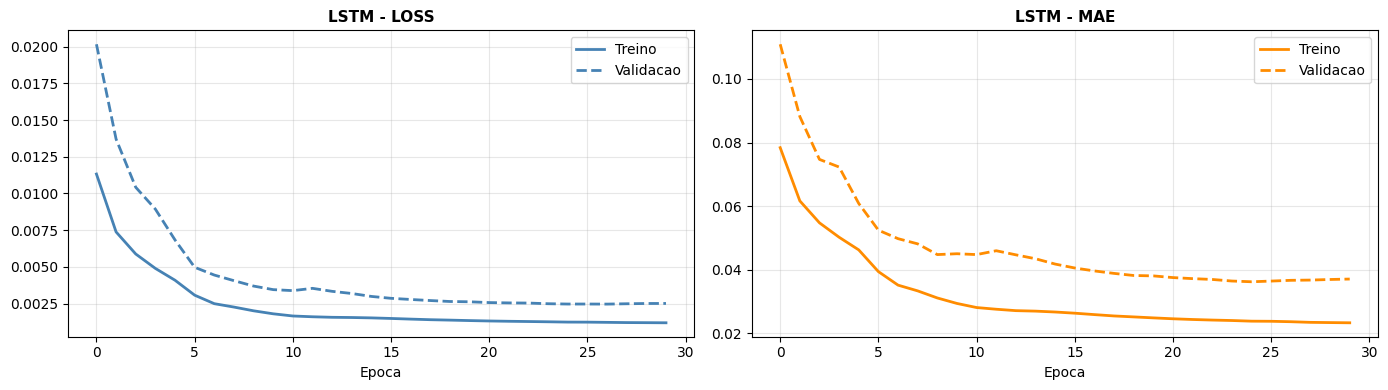

In [49]:
plotar_historico(hist_lstm, 'LSTM')


In [50]:
y_pred_lstm = desnormalizar_cnt(lstm.predict(X_teste).squeeze())
y_pred_lstm = garantir_contagens_validas(y_pred_lstm)
previsoes['LSTM'] = y_pred_lstm

m_lstm = calcular_metricas('LSTM', y_real_teste, y_pred_lstm)
resultados.append(m_lstm)
print(m_lstm)


109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
{'Modelo': 'LSTM', 'MAE': 34.08, 'RMSE': 48.79, 'R2': 0.9511, 'MAPE (%)': 57.32}


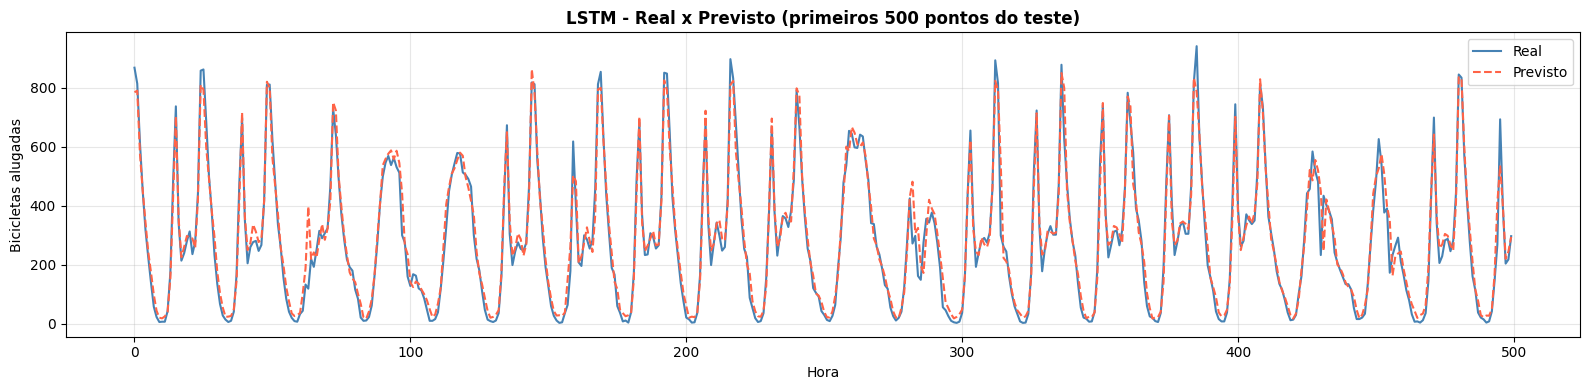

In [51]:
plotar_previsao(y_real_teste, y_pred_lstm, 'LSTM')


---
## Modelo 3 - GRU (Gated Recurrent Unit)

A GRU foi proposta em 2014 como alternativa mais simples a LSTM.
Usa apenas **dois portoes**:

| Portao | Funcao |
|--------|--------|
| **Reset gate** | Controla quanto da memoria anterior manter |
| **Update gate** | Combina estado anterior com novo estado |

**Vantagens:**
- Menos parametros que a LSTM -> treinamento mais rapido;
- Resultados geralmente equivalentes ou superiores a LSTM;
- Boa escolha quando o dataset nao e muito grande.


In [52]:
def criar_gru(n_steps, n_features, unidades):
    modelo = keras.Sequential([
        layers.Input(shape=(n_steps, n_features)),
        layers.GRU(unidades),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ], name='GRU')
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae'],
    )
    return modelo


gru = criar_gru(WINDOW_SIZE, N_FEATURES, UNITS)
gru.summary()


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,513 (64.50 KB)

 Trainable params: 16,513 (64.50 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
print('Treinando GRU...')
es = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=PATIENCE, restore_best_weights=True)

hist_gru = gru.fit(
    X_treino, y_treino,
    validation_split=VALIDATION,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    shuffle=False,
    verbose=1,
)
print(f'Concluido em {len(hist_gru.history["loss"])} epocas.')


Treinando GRU...
Epoch 1/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0115 - mae: 0.0797 - val_loss: 0.0153 - val_mae: 0.0900
Epoch 2/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0065 - mae: 0.0570 - val_loss: 0.0113 - val_mae: 0.0744
Epoch 3/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0049 - mae: 0.0486 - val_loss: 0.0092 - val_mae: 0.0674
Epoch 4/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0043 - mae: 0.0458 - val_loss: 0.0077 - val_mae: 0.0627
Epoch 5/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0039 - mae: 0.0444 - val_loss: 0.0063 - val_mae: 0.0572
Epoch 6/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0032 - mae: 0.0404 - val_loss: 0.0054 - val_mae: 0.0520
Epoch 7/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0026 - mae: 0.0358 - val_loss: 0.0042 - val_mae: 0.0459
Epoch 8/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0022 - mae: 0.0330 - val_loss: 0.0037 - val_mae: 0.0438
Epoch 9/30
185/185 ━━━━━━━━━━━━

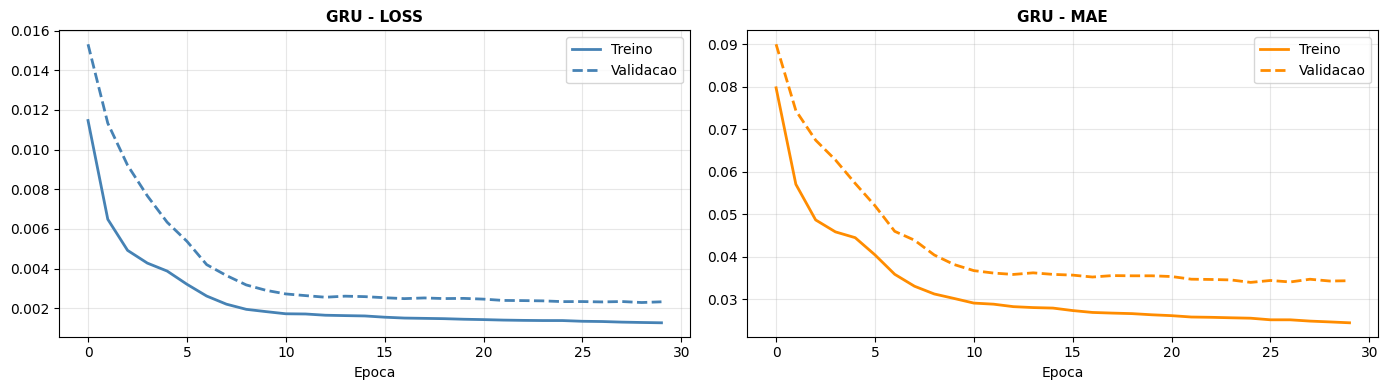

In [54]:
plotar_historico(hist_gru, 'GRU')


In [55]:
y_pred_gru = desnormalizar_cnt(gru.predict(X_teste).squeeze())
y_pred_gru = garantir_contagens_validas(y_pred_gru)
previsoes['GRU'] = y_pred_gru

m_gru = calcular_metricas('GRU', y_real_teste, y_pred_gru)
resultados.append(m_gru)
print(m_gru)


109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
{'Modelo': 'GRU', 'MAE': 35.53, 'RMSE': 51.98, 'R2': 0.9445, 'MAPE (%)': 41.36}


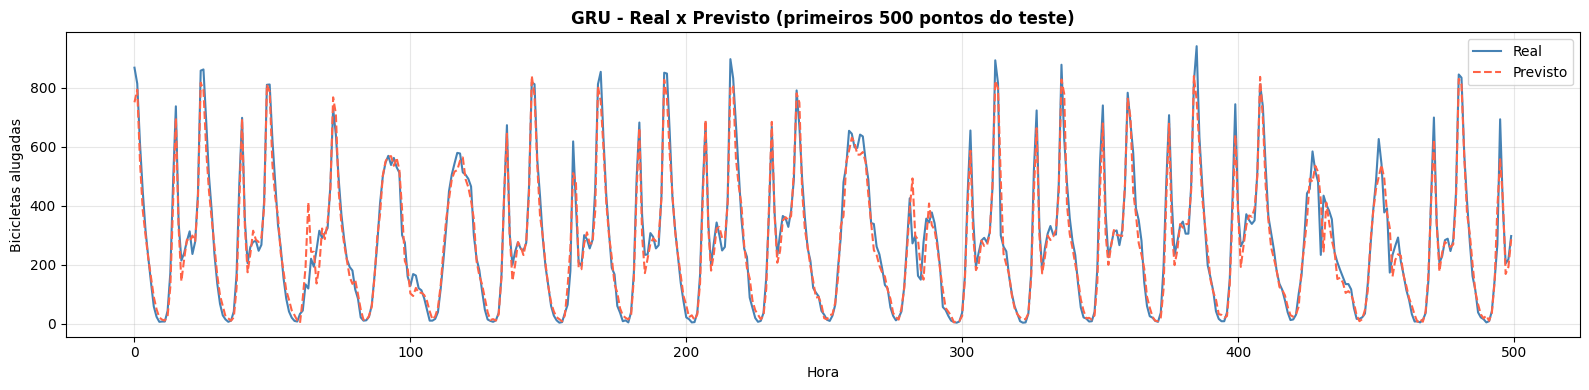

In [56]:
plotar_previsao(y_real_teste, y_pred_gru, 'GRU')


---
## Passo 9 - Comparacao dos Modelos


In [57]:
df_res = pd.DataFrame(resultados).set_index('Modelo')
print('=' * 52)
print('         COMPARACAO DE METRICAS')
print('=' * 52)
print(df_res.to_string())
print('=' * 52)
melhor = df_res['RMSE'].idxmin()
print(f'\nMelhor modelo (menor RMSE): {melhor}')


         COMPARACAO DE METRICAS
             MAE   RMSE      R2  MAPE (%)
Modelo                                   
SimpleRNN  41.54  58.08  0.9307     44.12
LSTM       34.08  48.79  0.9511     57.32
GRU        35.53  51.98  0.9445     41.36

Melhor modelo (menor RMSE): LSTM


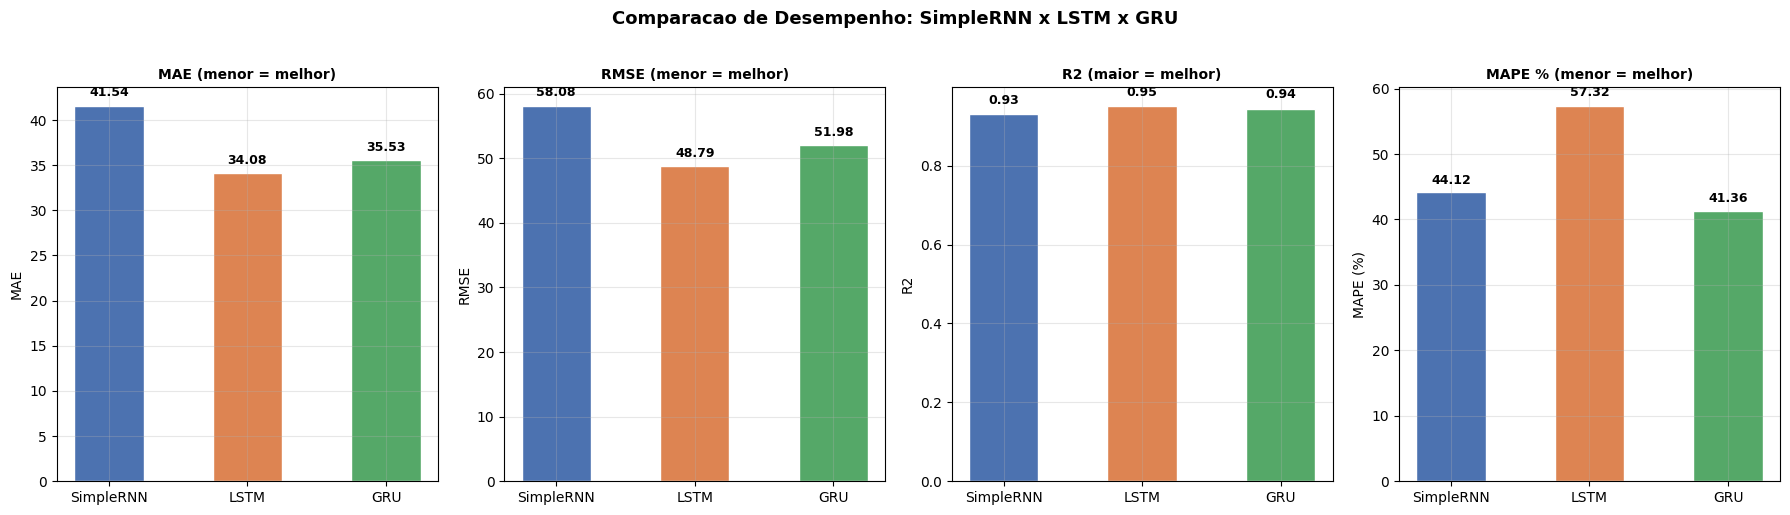

In [58]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
cores = ['#4C72B0', '#DD8452', '#55A868']
modelos = df_res.index.tolist()

metricas_info = [
    ('MAE',      'MAE (menor = melhor)'),
    ('RMSE',     'RMSE (menor = melhor)'),
    ('R2',       'R2 (maior = melhor)'),
    ('MAPE (%)', 'MAPE % (menor = melhor)'),
]

for ax, (col, titulo) in zip(axes, metricas_info):
    vals = df_res[col].values
    bars = ax.bar(modelos, vals, color=cores, edgecolor='white', width=0.5)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_ylabel(col)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Comparacao de Desempenho: SimpleRNN x LSTM x GRU',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparacao_metricas.png', dpi=120, bbox_inches='tight')
plt.show()


### Grafico Combinado: Real x Previsto (todos os modelos)


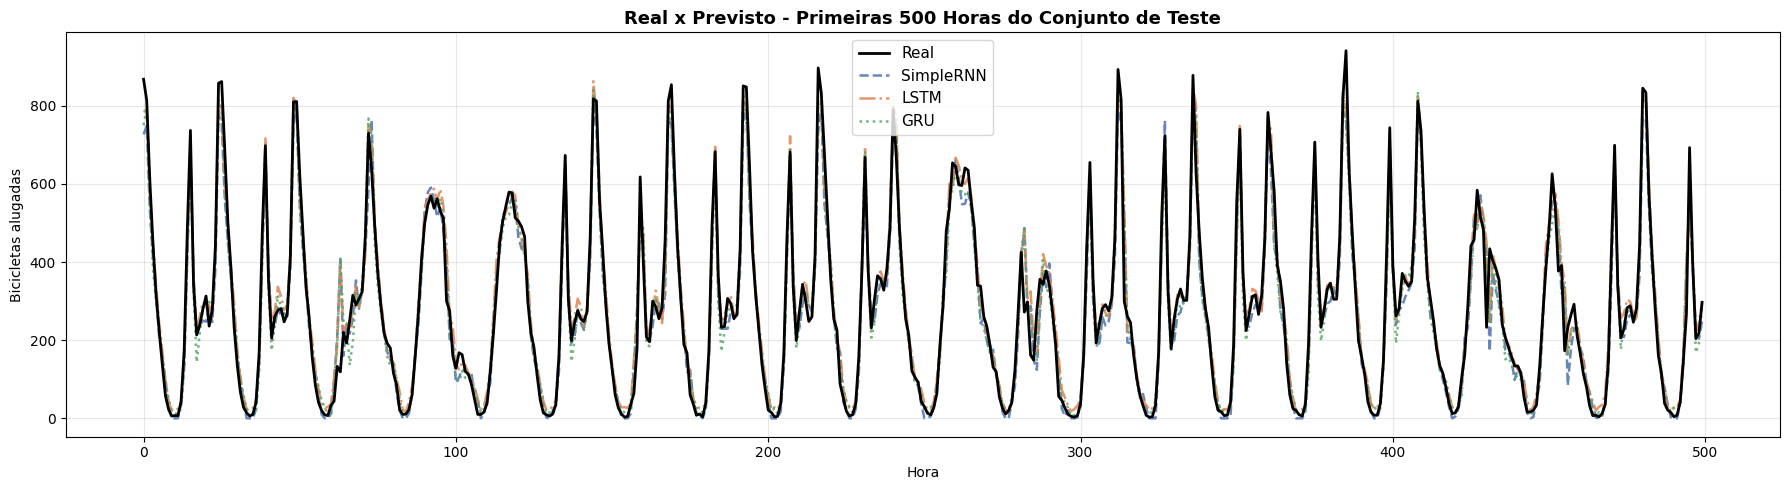

In [59]:
n = 500
plt.figure(figsize=(18, 5))
plt.plot(y_real_teste[:n], label='Real', color='black', lw=2, zorder=5)

estilos = {'SimpleRNN': '--', 'LSTM': '-.', 'GRU': ':'}
cores_m = {'SimpleRNN': '#4C72B0', 'LSTM': '#DD8452', 'GRU': '#55A868'}

for nome, pred in previsoes.items():
    plt.plot(pred[:n], label=nome,
             color=cores_m[nome], ls=estilos[nome], lw=1.8, alpha=0.85)

plt.title(f'Real x Previsto - Primeiras {n} Horas do Conjunto de Teste',
          fontsize=13, fontweight='bold')
plt.xlabel('Hora')
plt.ylabel('Bicicletas alugadas')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('real_vs_previsto_todos.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Passo 10 - Discussao e Limitacoes

### O que cada modelo captura?

#### SimpleRNN
- **Pontos fortes:** Simplicidade, treinamento rapido, bom para padroes de curto prazo.
- **Limitacoes:**
  - Sofre de *vanishing gradient* - dificuldade com dependencias de longo prazo;
  - Tende a suavizar picos de demanda;
  - Menos expressiva que LSTM e GRU.

#### LSTM
- **Pontos fortes:** Captura padroes de longo prazo; boa para sazonalidade semanal.
- **Limitacoes:**
  - Mais lenta para treinar (mais parametros);
  - Pode sobreajustar em datasets menores.

#### GRU
- **Pontos fortes:** Equilibrio velocidade vs capacidade; frequentemente iguala a LSTM.
- **Limitacoes:**
  - Sem *cell state* separado - pode ser menos expressiva em alguns casos.

### Limitacoes gerais dos modelos recorrentes

| # | Limitacao | Solucao possivel |
|---|-----------|------------------|
| 1 | Preve apenas 1 hora a frente | Arquitetura seq2seq |
| 2 | Nao captura eventos externos (greves, eventos) | Adicionar features de calendario |
| 3 | Dataset agrega toda a cidade | Modelos por estacao/bairro |
| 4 | Padrao de 2011-12 pode mudar | Re-treino periodico |
| 5 | Dificuldade com longas dependencias | Temporal Fusion Transformer |
| 6 | Variaveis como hora, dia da semana e estacao foram tratadas como ordinais | Testar codificacao ciclica ou embeddings |
| 7 | Algumas variaveis disponíveis foram omitidas para manter os modelos comparaveis e enxutos | Avaliar `mnth`, `holiday` e `atemp` por validacao temporal |
| 8 | A camada de saida linear pode gerar valores negativos | Restringir as previsoes ao dominio nao negativo |


---
## Conclusao

Foram construidos e comparados tres modelos recorrentes para prever a demanda
de bicicletas compartilhadas na hora seguinte.

| Etapa | O que fizemos |
|-------|---------------|
| **Analise exploratoria** | Identificamos padroes horarios e diarios, alem de variacoes ao longo da serie |
| **Pre-processamento** | Corte cronologico + MinMax ajustado no treino + janelas de 24 horas |
| **Modelagem** | SimpleRNN, LSTM e GRU treinados com EarlyStopping |
| **Avaliacao** | MAE, RMSE, R2 e MAPE calculados e comparados |
| **Visualizacao** | Curvas de treino + graficos Real x Previsto |

### Resultado da comparacao

Nesta execucao, a **LSTM apresentou o melhor desempenho geral**, com menor MAE
(34,08 bicicletas), menor RMSE (48,79 bicicletas) e maior R2 (0,9511). Isso
indica que o modelo explicou aproximadamente 95,1% da variabilidade observada
no conjunto de teste e apresentou os menores erros absolutos.

A **GRU obteve o menor MAPE (41,36%)**, superando a LSTM nessa metrica
percentual. Esse resultado mostra que a escolha do melhor modelo depende do
criterio operacional adotado. Para reduzir erros absolutos e penalizar desvios
maiores, a LSTM foi a melhor opcao nesta execucao; considerando apenas o erro
percentual medio, a GRU apresentou vantagem.

A SimpleRNN apresentou desempenho competitivo, mas ficou abaixo das
arquiteturas com mecanismos de portas. As diferencas entre execucoes tambem
podem ocorrer por causa da inicializacao estocastica e do treinamento das redes
neurais, mesmo com sementes definidas.

### Proximos passos sugeridos
- Repetir cada treinamento varias vezes e comparar media e desvio-padrao;
- Adicionar **Dropout** para regularizacao;
- Testar janelas maiores (48h, 72h);
- Avaliar codificacao ciclica para hora e dia da semana;
- Explorar **Temporal Fusion Transformer (TFT)**;
- Construir modelos por estacao para previsao granular.

---
_Dataset: Bike Sharing Dataset - UCI Machine Learning Repository._  
_Fanaee-T, Hadi, and Gama, Joao. Progress in Artificial Intelligence (2013)._
